# 3. Resource-demand model and elasticity analysis

This notebook estimates the independent execution, data, and state demand elasticities.

Historical gas-limit increases move the common base fee. They identify each resource's response along the common-price direction. The benchmark then imposes zero cross-price terms, so the common-price responses are interpreted as own-price elasticities.

The headline estimates use the first two gas-limit events. The third event is retained as a diagnostic because its post-period overlaps Fusaka and the first BPO blob-capacity increase.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.ardl import ardl_select_order

pd.options.display.float_format = "{:,.6f}".format
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 18,
})


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root")


PROJECT_ROOT = find_project_root(Path.cwd())
OUT_DIR = PROJECT_ROOT / "data" / "glamsterdam"
PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

DAILY_INPUT = OUT_DIR / "daily_resource_panel_2025-01-01_2026-05-31.csv"
EVENT_OUT = OUT_DIR / "elasticity_event_estimates.csv"
WINDOW_OUT = OUT_DIR / "elasticity_window_grid.csv"
VECTOR_OUT = OUT_DIR / "elasticity_vectors.csv"
ARDL_OUT = OUT_DIR / "elasticity_ardl_robustness.csv"
PLOT_OUT = PLOTS_DIR / "three_way_shares_2025.png"

if not DAILY_INPUT.exists():
    raise FileNotFoundError(f"Missing {DAILY_INPUT}. Run notebook 01 first.")

daily = pd.read_csv(DAILY_INPUT)
daily["date"] = pd.to_datetime(daily["date"])
daily.shape

(516, 17)

## Demand specification

For each resource (i), the benchmark demand curve is

$$
q_i(p_i)=q_i^0\left(\frac{p_i}{p^0}\right)^{-\epsilon_i}.
$$

The event study first estimates aggregate elasticity and the data/state responses relative to execution. At the 45M share anchor, those three statistics recover the independent resource elasticities.

In [2]:
RESOURCES = ["execution", "data", "state"]
EVENTS = [
    {"event": "30_to_36", "date": pd.Timestamp("2025-02-04"), "note": ""},
    {"event": "36_to_45", "date": pd.Timestamp("2025-07-21"), "note": ""},
    {
        "event": "45_to_60",
        "date": pd.Timestamp("2025-11-25"),
        "note": "post window overlaps Fusaka activation and BPO1",
    },
]
CLEAN_EVENTS = ["30_to_36", "36_to_45"]
WINDOWS = [21, 35, 60, 75]


def event_windows(event_date, window_days, exclude_days):
    pre_start = event_date - pd.Timedelta(days=exclude_days + window_days)
    pre_end = event_date - pd.Timedelta(days=exclude_days)
    post_start = event_date + pd.Timedelta(days=exclude_days + 1)
    post_end = event_date + pd.Timedelta(days=exclude_days + window_days)
    pre = daily[(daily["date"] >= pre_start) & (daily["date"] < pre_end)]
    post = daily[(daily["date"] >= post_start) & (daily["date"] <= post_end)]
    return pre, post


def pooled_stats(frame):
    blocks = frame["block_count"].sum()
    out = {
        resource: frame[f"q_{resource}"].sum() / blocks
        for resource in RESOURCES
    }
    out["gas_per_block"] = frame["block_gas_used"].sum() / blocks
    out["resource_total_per_block"] = frame["q_total"].sum() / blocks
    out["fee"] = frame["median_base_fee_per_gas"].median()
    return out


def event_estimate(spec, window_days=35, exclude_days=3):
    pre, post = event_windows(spec["date"], window_days, exclude_days)
    before = pooled_stats(pre)
    after = pooled_stats(post)
    dln_fee = np.log(after["fee"] / before["fee"])
    return {
        "event": spec["event"],
        "event_date": spec["date"].date().isoformat(),
        "window_days": window_days,
        "exclude_days": exclude_days,
        "pre_days": len(pre),
        "post_days": len(post),
        "dln_fee": dln_fee,
        "eps_agg_event": -np.log(
            after["gas_per_block"] / before["gas_per_block"]
        ) / dln_fee,
        "delta_state": -(
            np.log(after["state"] / after["execution"])
            - np.log(before["state"] / before["execution"])
        ) / dln_fee,
        "delta_data": -(
            np.log(after["data"] / after["execution"])
            - np.log(before["data"] / before["execution"])
        ) / dln_fee,
        "response_execution": -np.log(
            after["execution"] / before["execution"]
        ) / dln_fee,
        "response_data": -np.log(after["data"] / before["data"]) / dln_fee,
        "response_state": -np.log(after["state"] / before["state"]) / dln_fee,
        "note": spec["note"],
    }

## Event estimates

Each side of the main event comparison uses up to 35 days and excludes the three days surrounding the gas-limit change. Resource quantities are pooled per block, while the price statistic is the median of daily median base fees.

In [3]:
events_35 = pd.DataFrame([event_estimate(spec) for spec in EVENTS])
events_35.to_csv(EVENT_OUT, index=False)

event_table = events_35.copy()
anchor_45 = daily[
    (daily["segment"] == "event_panel") & (daily["gas_limit_mgas"] == 45)
]
anchor_shares = {
    resource: float(anchor_45[f"s_{resource}"].mean())
    for resource in RESOURCES
}

for index, row in event_table.iterrows():
    eps_execution = (
        row["eps_agg_event"]
        - anchor_shares["data"] * row["delta_data"]
        - anchor_shares["state"] * row["delta_state"]
    )
    event_table.loc[index, "eps_execution"] = eps_execution
    event_table.loc[index, "eps_data"] = eps_execution + row["delta_data"]
    event_table.loc[index, "eps_state"] = eps_execution + row["delta_state"]

event_table[
    [
        "event",
        "pre_days",
        "post_days",
        "dln_fee",
        "eps_agg_event",
        "delta_state",
        "delta_data",
        "eps_execution",
        "eps_data",
        "eps_state",
    ]
]

,event,pre_days,post_days,dln_fee,eps_agg_event,delta_state,delta_data,eps_execution,eps_data,eps_state
0,30_to_36,31,35,-2.114346,0.087306,0.311313,0.116765,0.018675,0.135440,0.329988
1,36_to_45,35,35,-0.886539,0.251278,0.116095,0.099868,0.223645,0.323513,0.339740
2,45_to_60,35,35,-1.254013,0.233533,0.233131,-0.094191,0.188714,0.094523,0.421845


## Window robustness and linked elasticity vectors

The model preserves each event-window estimate as a linked vector. It does not combine componentwise minima and maxima from different windows.

In [4]:
window_rows = []
for window_days in WINDOWS:
    for exclude_days in [3, 7]:
        for spec in EVENTS:
            row = event_estimate(spec, window_days, exclude_days)
            if row["pre_days"] >= 10 and row["post_days"] >= 10:
                window_rows.append(row)

window_grid = pd.DataFrame(window_rows)
window_grid.to_csv(WINDOW_OUT, index=False)

clean_window_means = (
    window_grid[
        window_grid["event"].isin(CLEAN_EVENTS)
        & window_grid["exclude_days"].eq(3)
    ]
    .groupby("window_days")[
        ["eps_agg_event", "delta_state", "delta_data"]
    ]
    .mean()
    .rename(columns={"eps_agg_event": "eps_agg"})
    .loc[WINDOWS]
)

vector_rows = []
for window_days, row in clean_window_means.iterrows():
    eps_execution = (
        row["eps_agg"]
        - anchor_shares["data"] * row["delta_data"]
        - anchor_shares["state"] * row["delta_state"]
    )
    vector_rows.append({
        "window_days": int(window_days),
        "exclude_days": 3,
        "eps_agg": float(row["eps_agg"]),
        "delta_data": float(row["delta_data"]),
        "delta_state": float(row["delta_state"]),
        "s_execution_anchor": anchor_shares["execution"],
        "s_data_anchor": anchor_shares["data"],
        "s_state_anchor": anchor_shares["state"],
        "eps_execution": eps_execution,
        "eps_data": eps_execution + row["delta_data"],
        "eps_state": eps_execution + row["delta_state"],
    })

elasticity_vectors = pd.DataFrame(vector_rows)
elasticity_vectors.to_csv(VECTOR_OUT, index=False)
elasticity_vectors

,window_days,exclude_days,eps_agg,delta_data,delta_state,s_execution_anchor,s_data_anchor,s_state_anchor,eps_execution,eps_data,eps_state
0,21,3,0.194893,0.084723,0.361371,0.756916,0.036208,0.206876,0.117067,0.201790,0.478438
1,35,3,0.169292,0.108317,0.213704,0.756916,0.036208,0.206876,0.121160,0.229476,0.334864
2,60,3,0.127086,0.123023,0.198007,0.756916,0.036208,0.206876,0.081668,0.204691,0.279676
3,75,3,0.119173,0.122880,0.175045,0.756916,0.036208,0.206876,0.078511,0.201391,0.253556


## Daily ARDL robustness

This is a robustness diagnostic, not the headline estimator. It examines changes in log resource ratios against changes in the log common fee. The event estimates remain primary because the ARDL residual diagnostics are weak, particularly for state.

In [5]:
def ardl_cumulative(series_name, frame, sample_label):
    work = frame[["date", series_name, "log_fee"]].copy()
    work["dy"] = work[series_name].diff()
    work["dx"] = work["log_fee"].diff()
    seam = work["date"].diff().dt.days > 1
    work.loc[seam, ["dy", "dx"]] = np.nan
    work = work.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    selected = ardl_select_order(
        work["dy"],
        10,
        work[["dx"]],
        10,
        ic="aic",
        trend="c",
        causal=False,
        glob=False,
    )
    result = selected.model.fit(cov_type="HAC", cov_kwds={"maxlags": 10})
    names = list(result.params.index)
    beta = np.array([1.0 if name.startswith("dx") else 0.0 for name in names])
    phi = np.array([1.0 if name.startswith("dy") else 0.0 for name in names])
    theta = result.params.values
    covariance = result.cov_params().values
    coefficient_sum = float(beta @ theta)
    own_lag_sum = float(phi @ theta)
    standard_error = float(np.sqrt(beta @ covariance @ beta))
    critical_value = stats.t.ppf(0.975, result.df_resid)
    ljung_box = acorr_ljungbox(result.resid, lags=[30], model_df=result.df_model)

    return {
        "series": series_name,
        "sample": sample_label,
        "selected_order": str(selected.model.ardl_order),
        "nobs": int(result.nobs),
        "delta_cumulative": -coefficient_sum,
        "delta_ci_low": -(coefficient_sum + critical_value * standard_error),
        "delta_ci_high": -(coefficient_sum - critical_value * standard_error),
        "delta_longrun": -coefficient_sum / (1 - own_lag_sum),
        "ljung_box_lag30_pvalue": float(ljung_box["lb_pvalue"].iloc[0]),
    }


ardl_results = pd.DataFrame([
    ardl_cumulative(series, frame, label)
    for series in ["log_odds_data", "log_odds_state"]
    for label, frame in {
        "2025_event_panel": daily[daily["segment"] == "event_panel"],
        "full_sample": daily,
    }.items()
])
ardl_results.to_csv(ARDL_OUT, index=False)
ardl_results

,series,sample,selected_order,nobs,delta_cumulative,delta_ci_low,delta_ci_high,delta_longrun,ljung_box_lag30_pvalue
0,log_odds_data,2025_event_panel,"(7, 7)",361,0.404159,0.260523,0.547794,0.138025,0.001634
1,log_odds_data,full_sample,"(10, 7)",505,0.310216,0.199695,0.420737,0.104936,0.006260
2,log_odds_state,2025_event_panel,"(7, 6)",361,1.075158,0.681498,1.468818,0.492650,0.000013
3,log_odds_state,full_sample,"(7, 6)",508,1.064641,0.756534,1.372749,0.478016,0.000000


## Resource quantities, shares, fees, and relative responses

This is the figure embedded in the report.

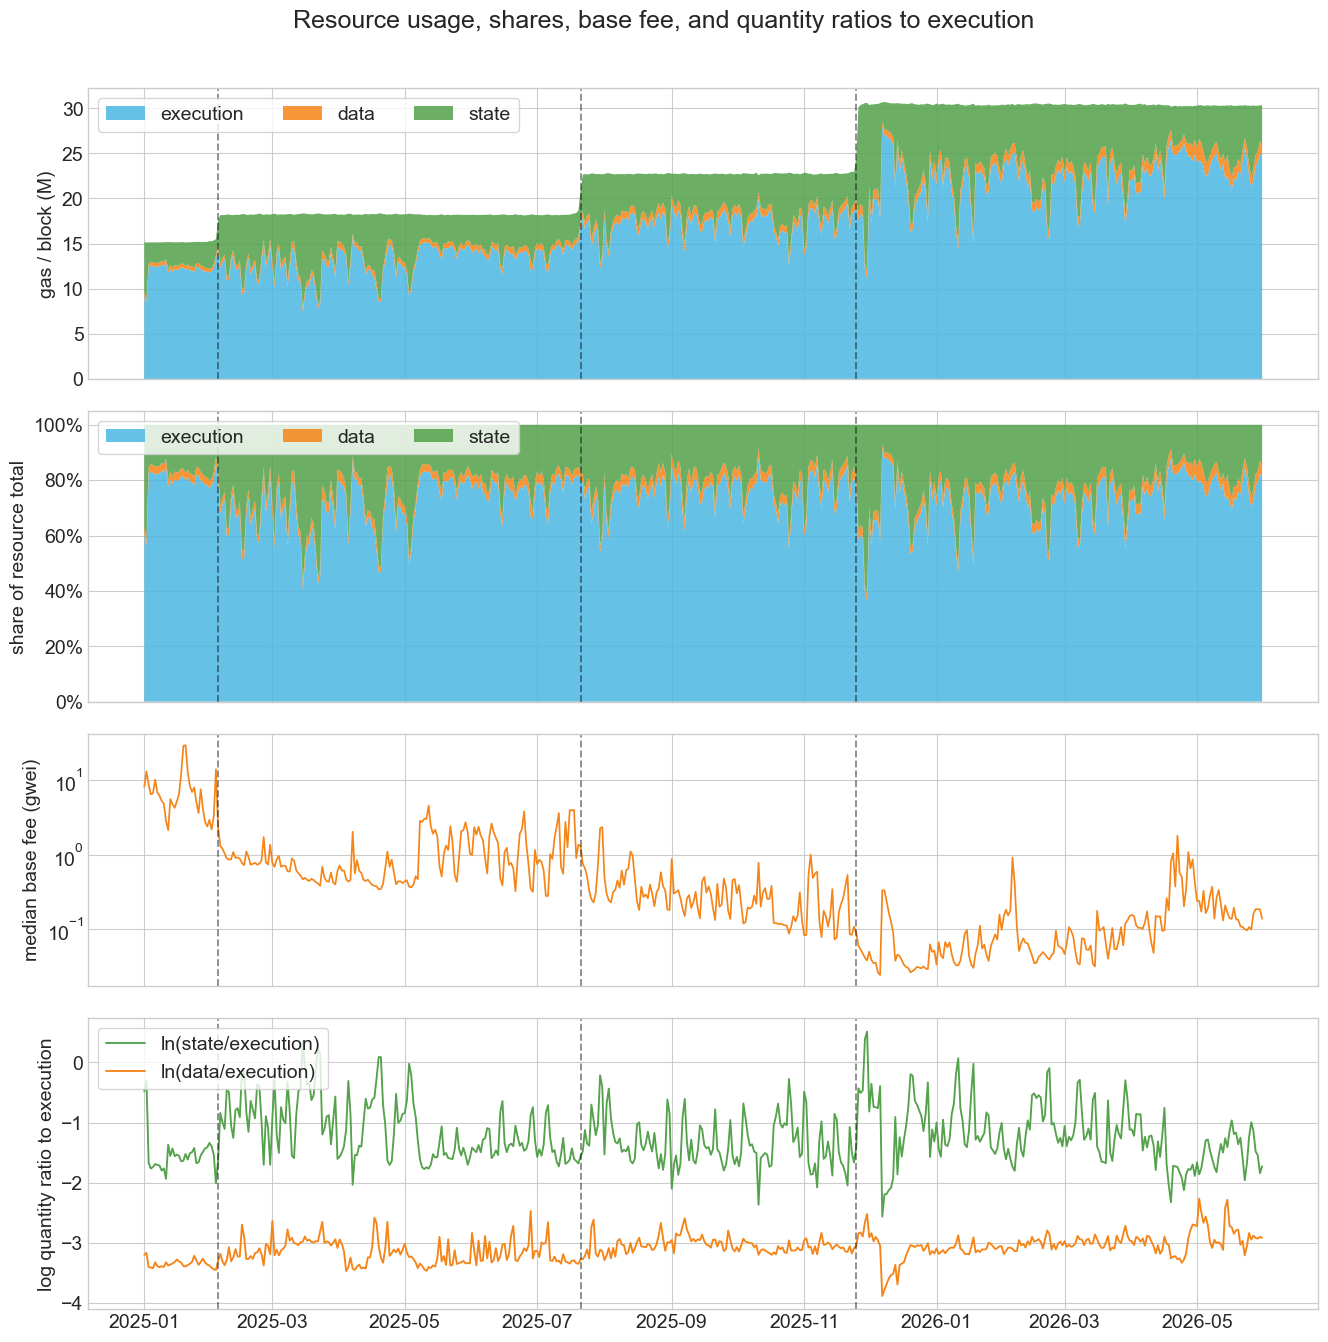

Wrote plots/three_way_shares_2025.png


In [6]:
RESOURCE_COLORS = {
    "execution": "#4CB7E1",
    "data": "#F58518",
    "state": "#54A24B",
}

fig, axes = plt.subplots(
    4,
    1,
    figsize=(13.5, 13.5),
    sharex=True,
    gridspec_kw={"height_ratios": [1.15, 1.15, 1.0, 1.15]},
)

axes[0].stackplot(
    daily["date"],
    daily["q_execution"] / daily["block_count"] / 1e6,
    daily["q_data"] / daily["block_count"] / 1e6,
    daily["q_state"] / daily["block_count"] / 1e6,
    labels=["execution", "data", "state"],
    alpha=0.86,
    colors=[RESOURCE_COLORS[name] for name in RESOURCES],
)
axes[0].set_ylabel("gas / block (M)")
axes[0].legend(loc="upper left", ncols=3, frameon=True)

axes[1].stackplot(
    daily["date"],
    daily["s_execution"],
    daily["s_data"],
    daily["s_state"],
    labels=["execution", "data", "state"],
    alpha=0.86,
    colors=[RESOURCE_COLORS[name] for name in RESOURCES],
)
axes[1].set_ylabel("share of resource total")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].legend(loc="upper left", ncols=3, frameon=True)

axes[2].plot(
    daily["date"],
    daily["median_base_fee_per_gas"] / 1e9,
    color="#F58518",
    linewidth=1.25,
)
axes[2].set_ylabel("median base fee (gwei)")
axes[2].set_yscale("log")

axes[3].plot(
    daily["date"],
    daily["log_odds_state"],
    linewidth=1.35,
    label="ln(state/execution)",
    color=RESOURCE_COLORS["state"],
)
axes[3].plot(
    daily["date"],
    daily["log_odds_data"],
    linewidth=1.35,
    label="ln(data/execution)",
    color=RESOURCE_COLORS["data"],
)
axes[3].set_ylabel("log quantity ratio to execution")
axes[3].legend(loc="upper left", frameon=True)

for axis in axes:
    for spec in EVENTS:
        axis.axvline(
            spec["date"],
            linestyle="--",
            color="black",
            alpha=0.45,
            linewidth=1.35,
        )

fig.suptitle(
    "Resource usage, shares, base fee, and quantity ratios to execution",
    y=0.995,
)
fig.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig(PLOT_OUT, dpi=180)
plt.show()

print(f"Wrote {PLOT_OUT.relative_to(PROJECT_ROOT)}")

## Validation and handoff

Notebook 04 reads the four linked rows in `elasticity_vectors.csv`. The 75-day row remains an extended sensitivity because the first event has only 31 available pre-event days.

In [7]:
expected_ranges = {
    "eps_execution": (0.079, 0.121),
    "eps_data": (0.201, 0.229),
    "eps_state": (0.254, 0.478),
}
for column, (expected_min, expected_max) in expected_ranges.items():
    observed_min = elasticity_vectors[column].min()
    observed_max = elasticity_vectors[column].max()
    assert np.isclose(observed_min, expected_min, atol=5e-4), (
        column,
        observed_min,
        expected_min,
    )
    assert np.isclose(observed_max, expected_max, atol=5e-4), (
        column,
        observed_max,
        expected_max,
    )

assert (
    elasticity_vectors["eps_state"] > elasticity_vectors["eps_data"]
).all()
assert (
    elasticity_vectors["eps_data"] > elasticity_vectors["eps_execution"]
).all()
assert elasticity_vectors["window_days"].tolist() == WINDOWS

elasticity_vectors[
    [
        "window_days",
        "eps_agg",
        "delta_data",
        "delta_state",
        "eps_execution",
        "eps_data",
        "eps_state",
    ]
]

,window_days,eps_agg,delta_data,delta_state,eps_execution,eps_data,eps_state
0,21,0.194893,0.084723,0.361371,0.117067,0.201790,0.478438
1,35,0.169292,0.108317,0.213704,0.121160,0.229476,0.334864
2,60,0.127086,0.123023,0.198007,0.081668,0.204691,0.279676
3,75,0.119173,0.122880,0.175045,0.078511,0.201391,0.253556
